In [108]:
#single amplitude 1/0 margin
import sys
print(sys.executable)

C:\Users\allen\AppData\Local\Programs\Python\Python312\python.exe


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
import subprocess
import re

In [73]:
def picking_time_frames(time, write_0, write_1):
    """ Looks at values in write_0 and write_1 and return the time intervals in which the values are non zero.
        Returns a dictionary with keys write_0 and write_1 with corresponding time intervals as tuples."""
    def find_intervals(signal):
        intervals = []
        start_idx = None
        for i, value in enumerate(signal):
            if value != 0 and start_idx is None:
                start_idx = i
            elif value == 0 and start_idx is not None:
                intervals.append((time[start_idx], time[i-1]))
                start_idx = None
        if start_idx is not None:
            intervals.append((time[start_idx], time[-1]))
        return intervals
    return {
        'write_0': find_intervals(write_0),
        'write_1': find_intervals(write_1)
    }
def calc_charges(time_intervals, time, current):
    """takes a dictionary with keys of corresponding time intervals and integrates current in those intervals.
        Returns another dictionary with write_1 and write_0 keys and list of corresponding charges."""
    charges = {'write_0': [], 'write_1': []}
    for key in ['write_0', 'write_1']:
        for start_time, end_time in time_intervals.get(key, []):
            #identify indices corresponding to the current interval
            indices = np.where((time >= start_time) & (time <= end_time))[0]
            if len(indices) > 1:
                #extract the time and current values for the interval
                interval_time = time[indices]
                interval_current = current[indices]
                #integrate
                charge = simpson(interval_current, x=interval_time)
                charges[key].append(charge)
            else:
                #if not enough points are found, append zero charge
                charges[key].append(0.0)
    return charges
def parse_amp_data(filename):
    """
    Custom parser that looks for 'Step Information: Amp=' lines
    and numeric lines, skipping the header line.
    """
    import pandas as pd

    blocks = []
    current_block = None

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            
            # Skip the header line
            if line.startswith("time"):
                continue  # just ignore this line and move on

            if line.startswith("Step Information: Amp="):
                # If we were already collecting rows in a current_block, store it
                if current_block is not None and current_block['rows']:
                    blocks.append(current_block)
                
                # Now parse the Amp label, e.g. "Step Information: Amp=1p  (Step: 2/21)"
                after_amp_equals = line.split("Amp=")[1].strip()
                amp_label = after_amp_equals.split()[0]
                
                # Example conversion:
                if amp_label.endswith('p'):
                    # "1p" => 1 × 10^-12
                    val = float(amp_label[:-1])
                    amp_value = val
                else:
                    # e.g. "1e-12", "2", etc.
                    amp_value = float(amp_label)
                
                current_block = {
                    'amp': amp_value,
                    'rows': []
                }
            
            elif not line:
                continue
            
            else:
                parts = line.split()
                # Must have 6 columns: time, V_read, Write_0, Write_1, V_mem, I(Read)
                if len(parts) == 6:
                    row = {
                        'time':    float(parts[0]),
                        'V_read':  float(parts[1]),
                        'Write_0': float(parts[2]),
                        'Write_1': float(parts[3]),
                        'V_mem':   float(parts[4]),
                        'I(Read)': float(parts[5])
                    }
                    if current_block is not None:
                        current_block['rows'].append(row)
    
    # After finishing reading
    if current_block is not None and current_block['rows']:
        blocks.append(current_block)

    # Convert each block to DataFrame
    all_dfs = []
    for block in blocks:
        df_block = pd.DataFrame(block['rows'])
        df_block['Amp'] = block['amp']
        all_dfs.append(df_block)
    
    df_total = pd.concat(all_dfs, ignore_index=True)
    return df_total

            time  V_read  Write_0  Write_1         V_mem       I(Read)   Amp
0       0.000000     0.0      0.0      0.0  0.000000e+00  0.000000e+00   0.0
1       3.004194     0.0      0.0      0.0 -1.328254e-24  3.943812e-31   0.0
2       6.076194     0.0      0.0      0.0 -2.111055e-24  6.196209e-30   0.0
3       9.148194     0.0      0.0      0.0 -2.712027e-24  1.294611e-29   0.0
4      12.220194     0.0      0.0      0.0 -2.895549e-24  2.060125e-29   0.0
...          ...     ...      ...      ...           ...           ...   ...
4616  343.993194     0.0      0.0      0.0 -1.367186e-12  3.787112e-19  20.0
4617  347.065194     0.0      0.0      0.0 -1.422862e-12 -3.032886e-18  20.0
4618  350.137194     0.0      0.0      0.0 -1.372537e-12 -3.310910e-18  20.0
4619  350.998194     0.0      0.0      0.0 -1.278803e-12  7.170872e-19  20.0
4620  351.000000     0.0      0.0      0.0 -1.278649e-12  7.292533e-19  20.0

[4621 rows x 7 columns]
{'write_0': [0], 'write_1': [0]}
{'write_0': [np.fl

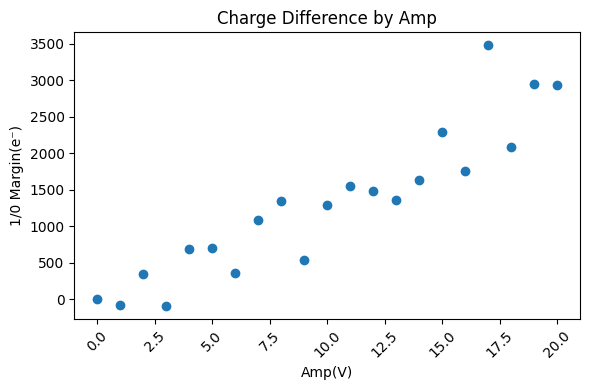

Amp with max charge difference: 17.0
Corresponding ChargeDiff: 3478.242377327127


In [83]:
#1/0 margin plot vs. amp param

# create the right dataframe
df = parse_amp_data(r"OneDrive\GC-College\stuff\PHz-electronics-UROP-project\Memcell_param_sweep_3.txt")
print(df)
# We'll create an empty list to hold (amp, difference) pairs
amp_diffs = []

# 1) Group by Amp
for amp_value, df_amp in df.groupby('Amp'):
    # 2) Extract arrays
    time_array     = df_amp['time'].values
    write0_array   = df_amp['Write_0'].values
    write1_array   = df_amp['Write_1'].values
    current_array  = df_amp['I(Read)'].values
    
    # 3) Find intervals
    intervals = picking_time_frames(time_array, write0_array, write1_array)
    
    # 4) Calculate charges
    charges_dict = calc_charges(intervals, time_array, current_array)
    if charges_dict['write_0'] == [] and charges_dict['write_1'] == []:
        charges_dict['write_0'].append(0)
        charges_dict['write_1'].append(0)
    print(charges_dict)
    # 5) find the first charge of each state
    total_write_0 = charges_dict['write_0'][0]
    total_write_1 = charges_dict['write_1'][0]
    
    # 6) Difference
    difference = (total_write_1 - total_write_0)/(1.602e-19)
    
    # 7) Store in our list
    amp_diffs.append((amp_value, difference))

# Convert to a small DataFrame
df_diffs = pd.DataFrame(amp_diffs, columns=['Amp', 'ChargeDiff'])

#sort amp in the order you want them to appear on the x-axis:
df_diffs.sort_values('Amp', inplace=True, key=lambda col: col.astype(str))

# 8) Plot
plt.figure(figsize=(6,4))
plt.scatter(df_diffs['Amp'], df_diffs['ChargeDiff'])
plt.xlabel('Amp(V)')
plt.ylabel('1/0 Margin(e\u207B)')
plt.title('Charge Difference by Amp')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#finding max charge diff
max_idx = df_diffs["ChargeDiff"].idxmax()
amp_at_max = df_diffs.loc[max_idx, "Amp"]
max_diff = df_diffs.loc[max_idx, "ChargeDiff"]
print("Amp with max charge difference:", amp_at_max)
print("Corresponding ChargeDiff:", max_diff)

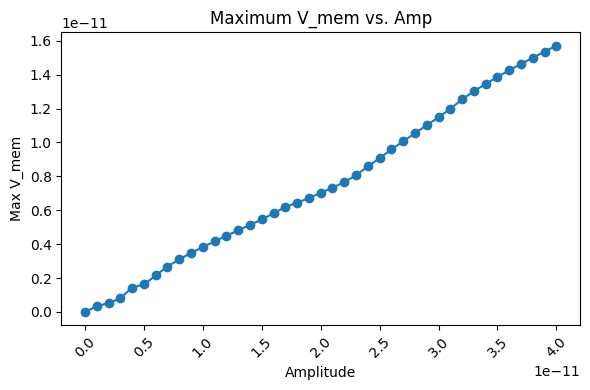

In [64]:
#plotting max V_mem vs amplitude
ldf = parse_amp_data(r"Downloads\Getting started\Getting started\nanoantenna_component_files\Memcell_large_param_sweep.txt")
ldf_max_vmem = ldf.groupby('Amp', as_index=False)['V_mem'].max()
ldf_max_vmem.sort_values('Amp', inplace=True)
plt.figure(figsize=(6,4))
plt.plot(ldf_max_vmem['Amp'], ldf_max_vmem['V_mem'], marker='o', linestyle='-')
plt.xlabel('Amplitude')
plt.ylabel('Max V_mem')
plt.title('Maximum V_mem vs. Amp')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

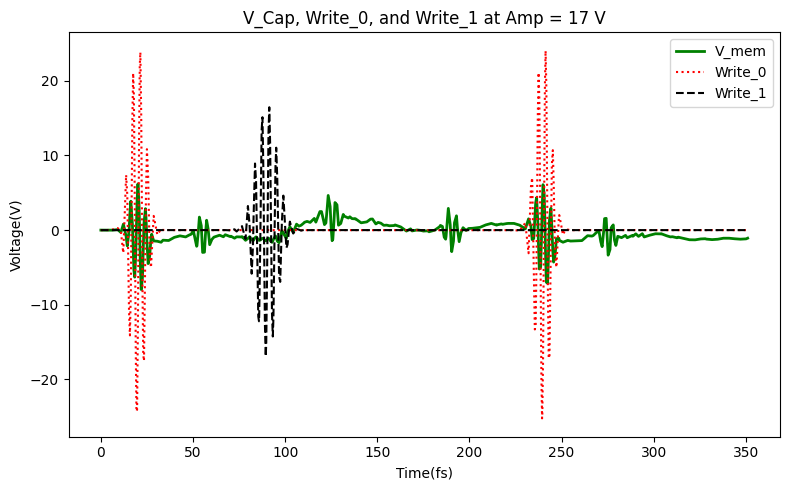

In [93]:
#V_mem vs. time for max charge diff amp
df_amp_1_7e11 = df[df['Amp'] == 17]
plt.figure(figsize=(8,5))

# 3) Plot V_mem (voltage) vs. time
plt.plot(df_amp_1_7e11['time'], df_amp_1_7e11['V_mem']*1e12, label='V_mem', linewidth=2, color='g')

# 4) Plot Write_0 vs. time
plt.plot(df_amp_1_7e11['time'], df_amp_1_7e11['Write_0']*1e12, label='Write_0', linestyle=':',color='r')

# 5) Plot Write_1 vs. time
plt.plot(df_amp_1_7e11['time'], df_amp_1_7e11['Write_1']*1e12, label='Write_1', linestyle='--', color='k')
plt.xlabel('Time(fs)')
plt.ylabel('Voltage(V)')
plt.title('V_Cap, Write_0, and Write_1 at Amp = 17 V')
plt.legend()
plt.tight_layout()
plt.show()

In [132]:
#gradient descent
def compute_objective_from_file(filename='memcell_data.txt'):
    """Reads the data file from LTspice, computes f = Qread1 - Qread0."""
    df = pd.read_csv(filename, delim_whitespace=True)
    time_frames = picking_time_frames(df["time"], df["Write_0"], df["Write_1"])
    charges = calc_charges(time_frames, df["time"], df["I(Read)"])
    Qread1 = sum(charges["write_1"])
    Qread0 = sum(charges["write_0"])
    return Qread1 - Qread0
def set_ltspice_params(asc_file, param_dict, out_file='Downloads\Getting started\Getting started\nanoantenna_component_files\Memcell_with_nanoantennav2.asc'):
    with open(asc_file, 'r') as f:
        asc_data = f.read()
    
    for p_name, p_val in param_dict.items():
        # Convert numeric values directly to strings without escaping
        p_val_str = str(p_val)  # No re.escape here

        # Regex pattern to find ".param p_name = oldValue"
        pattern = rf"(\.param\s+{p_name}\s*=\s*)([^\s]+)"
        
        def replace_func(m):
            # m.group(1) is the ".param p_name =" portion
            return m.group(1) + p_val_str
        
        asc_data = re.sub(pattern, replace_func, asc_data)

    with open(out_file, 'w') as f:
        f.write(asc_data)
    
    return out_file


def run_ltspice_and_get_f_value(param_dict,
                                asc_template=r"Downloads\Getting started\Getting started\nanoantenna_component_files\Memcell_with_nanoantennav2.asc",
                                asc_modified=r'Downloads\Getting started\Getting started\nanoantenna_component_files\Memcell_with_nanoantennav2_copy.asc',
                                data_file='memcell_data.txt'):
    """
    param_dict: dictionary of {param_name: value}
    Returns f = Qread1 - Qread0 from the simulator output
    """
    # 1) Modify the netlist (or .asc file) with new parameters
    modified_file = set_ltspice_params(asc_template, param_dict, out_file=asc_modified)
    
    # 2) Run LTspice in batch mode
    subprocess.run([
        r"C:\Users\allen\AppData\Local\Programs\ADI\LTspice\LTspice.exe",  # Adjust path as needed
        "-Run", "-b", modified_file
    ], check=True)
    
    # 3) Parse the resulting data
    f_value = compute_objective_from_file(filename=data_file)
    return f_value

def black_box_objective(params_tensor):
    """
    This function is a tf.function, but inside it, we'll do a 'py_function' 
    to run the external black box. We'll still need a numeric gradient approach.
    """
    def _run_ltspice_py(params_np):
        # Convert numpy array -> dictionary
        # Suppose param order: [amp, freq, sigdur, csigdur]
        param_dict = {
            'amp':     float(params_np[0]),
            'freq':    float(params_np[1]),
            'sigdur':  float(params_np[2]),
            'csigdur': float(params_np[3])
        }
        return run_ltspice_and_get_f_value(param_dict)
    
    # Use tf.py_function to wrap a Python call returning a float
    result = tf.py_function(_run_ltspice_py, [params_tensor], Tout=tf.float32)
    return result
import numpy as np

def numeric_gradient_descent_np(initial_params, num_iterations=5, delta=1e-2, lr=1e-3):
    """
    initial_params: list or np.array of initial guesses, e.g. [3e-11, 0.26, 5.6, 4.0]
    num_iterations: how many gradient descent steps to take
    delta: step for finite difference
    lr: learning rate
    """
    # Convert initial_params to a NumPy array
    params = np.array(initial_params, dtype=np.float64)

    for i in range(num_iterations):
        # 1) Evaluate objective at current params
        f_current = black_box_objective(params)

        # 2) Compute numeric gradient for each dimension
        grads = np.zeros_like(params)
        for idx in range(params.size):
            # Save the original parameter value
            original_val = params[idx]

            # +delta
            params[idx] = original_val + delta
            f_plus = black_box_objective(params)

            # -delta
            params[idx] = original_val - delta
            f_minus = black_box_objective(params)

            # Reset to original value
            params[idx] = original_val

            # Compute finite difference gradient
            grads[idx] = (f_plus - f_minus) / (2.0 * delta)

        # 3) Update parameters using the gradient
        old_params = params.copy()
        params += lr * grads

        # Log the parameter changes
        print(f"Iteration {i} | f={f_current:.6g}")
        print(f"Params changed: {params - old_params}")

    return params
init_params = [3e-11, 0.26, 5.6, 4.0]  # [amp, freq, sigdur, csigdur]
optimized_params = numeric_gradient_descent_np(
        initial_params=init_params,
        num_iterations=3,  # Number of iterations
        delta=1,         # Delta for finite difference
        lr=1            # Learning rate
    )
print("Optimized parameters:", optimized_params)

<>:10: SyntaxWarning: invalid escape sequence '\G'
<>:10: SyntaxWarning: invalid escape sequence '\G'
C:\Users\allen\AppData\Local\Temp\ipykernel_33068\1983671286.py:10: SyntaxWarning: invalid escape sequence '\G'
  def set_ltspice_params(asc_file, param_dict, out_file='Downloads\Getting started\Getting started\nanoantenna_component_files\Memcell_with_nanoantennav2.asc'):
C:\Users\allen\AppData\Local\Temp\ipykernel_33068\1983671286.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True)
C:\Users\allen\AppData\Local\Temp\ipykernel_33068\1983671286.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True)
C:\Users\allen\AppData\Local\Temp\ipykernel_33068\1983671286.py:4: FutureWarning: The 'delim_whitespace

Iteration 0 | f=4.95443e-16
Params changed: [0. 0. 0. 0.]


C:\Users\allen\AppData\Local\Temp\ipykernel_33068\1983671286.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True)
C:\Users\allen\AppData\Local\Temp\ipykernel_33068\1983671286.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True)
C:\Users\allen\AppData\Local\Temp\ipykernel_33068\1983671286.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True)
C:\Users\allen\AppData\Local\Temp\ipykernel_33068\1983671286.py:10: SyntaxWarning: invalid escape sequence '\G'
  def set_ltspice_params(asc_file, param_dict, out_file='Downloads\Getting started\Getting started\nanoan

UnknownError: {{function_node __wrapped__EagerPyFunc_Tin_1_Tout_1_device_/job:localhost/replica:0/task:0/device:CPU:0}} KeyboardInterrupt: 
Traceback (most recent call last):

  File "C:\Users\allen\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\ops\script_ops.py", line 267, in __call__
    return func(device, token, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^

  File "C:\Users\allen\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\ops\script_ops.py", line 145, in __call__
    outputs = self._call(device, args)
              ^^^^^^^^^^^^^^^^^^^^^^^^

  File "C:\Users\allen\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\ops\script_ops.py", line 152, in _call
    ret = self._func(*args)
          ^^^^^^^^^^^^^^^^^

  File "C:\Users\allen\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\autograph\impl\api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^